In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../backend/datasets/water_consumption_processed.csv"
)

df.head()

,Date,Time,Consumption,Temperature,Rain,Sun,StartTime,Datetime,Hour,Day,Month,DayOfWeek,IsWeekend
0,1/1/2016,00:00-01:00,1480,0.6,0.0,0,00:00,2016-01-01 00:00:00,0,1,1,4,0
1,1/1/2016,01:00-02:00,1362,0.6,0.0,0,01:00,2016-01-01 01:00:00,1,1,1,4,0
2,1/1/2016,02:00-03:00,1296,0.5,0.0,0,02:00,2016-01-01 02:00:00,2,1,1,4,0
3,1/1/2016,03:00-04:00,1096,0.0,0.0,0,03:00,2016-01-01 03:00:00,3,1,1,4,0
4,1/1/2016,04:00-05:00,810,0.3,0.0,0,04:00,2016-01-01 04:00:00,4,1,1,4,0


In [18]:
df.shape
df.columns

Index(['Date', 'Time', 'Consumption', 'Temperature', 'Rain', 'Sun',
       'StartTime', 'Datetime', 'Hour', 'Day', 'Month', 'DayOfWeek',
       'IsWeekend'],
      dtype='object')

In [19]:
features = [
    "Temperature",
    "Rain",
    "Sun",
    "Hour",
    "Day",
    "Month",
    "DayOfWeek",
    "IsWeekend"
]

X=df[features]
y=df["Consumption"]

X.head()
y.head()

0    1480
1    1362
2    1296
3    1096
4     810
Name: Consumption, dtype: int64

In [20]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 36824
Testing samples: 9207


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_predictions
})

comparison.head(10)

,Actual,Predicted
0,2925,2857.42
1,3863,3898.39
2,4060,3821.73
3,3878,3672.61
4,3570,3419.59
5,3323,3172.36
6,2900,2924.62
7,2768,2735.31
8,2659,2539.61
9,2735,2618.44


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, rf_predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

r2 = r2_score(y_test, rf_predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²   :", r2)

MAE : 401.1034636689476
RMSE: 512.5792339742079
R²   : 0.7871673940036562


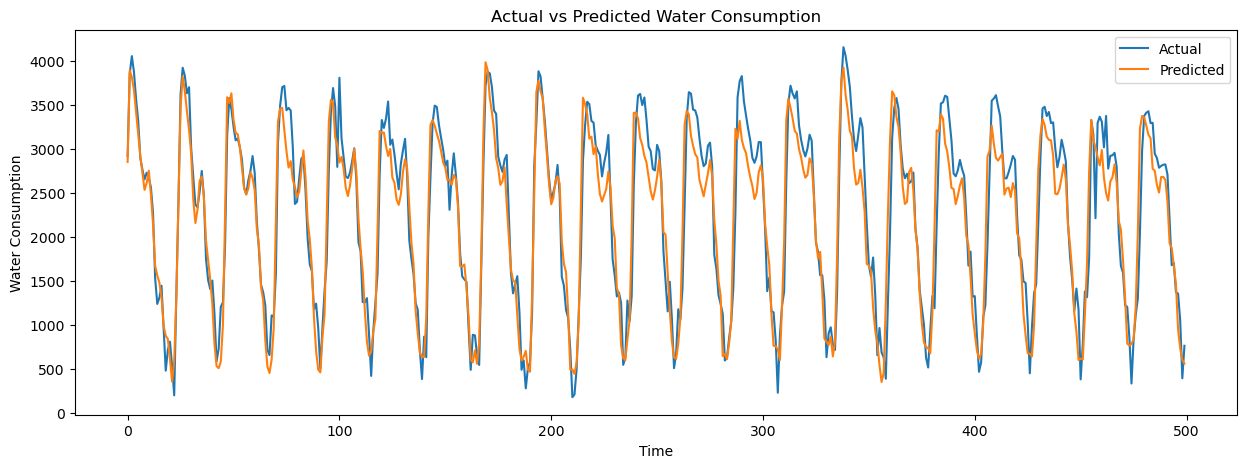

In [30]:
plt.figure(figsize=(15, 5))

plt.plot(
    y_test.values[:500],
    label="Actual"
)

plt.plot(
    rf_predictions[:500],
    label="Predicted"
)

plt.xlabel("Time")
plt.ylabel("Water Consumption")
plt.title("Actual vs Predicted Water Consumption")

plt.legend()
plt.show()